<a href="https://colab.research.google.com/github/zakyalkhair/alfagift-sentiment-analysis/blob/main/homework/tf-idf/1a-danantara.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Dependencies

In [100]:

import nltk
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
!pip install Sastrawi
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Download resource NLTK yang dibutuhkan sekali saja
nltk.download('punkt')
nltk.download('punkt_tab')

import nltk
from nltk.tokenize import sent_tokenize
nltk.download('punkt')
from sklearn.feature_extraction.text import TfidfVectorizer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# 2. Define Document

In [101]:
document_text = """Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar. Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.

Pemerintah Republik Indonesia dan Pemerintah Qatar menggelar diskusi untuk menyepakati kemitraan strategis (co-partnership) dalam pengelolaan dana investasi untuk Indonesia yang akan berfokus di berbagai sektor pembangunan.

Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar. Dana ini akan difokuskan pada pengembangan berbagai sektor di antaranya termasuk tapi tidak terbatas pada hilirisasi industri, energi terbarukan, dan fasilitas kesehatan di Indonesia.

"Kami menyambut baik kepercayaan yang diberikan oleh Pemerintah Qatar melalui pembentukan dana bersama ini," kata CEO Danantara Indonesia Rosan Perkasa Roeslani dalam keterangan tertulis, Selasa, 15 April 2025.

Presiden Prabowo menyampaikan masing-masing negara akan berkontribusi sebesar USD2 miliar dalam dana tersebut. Dana itu akan dikelola oleh BPI Danantara bersama dengan Qatar Investment Authority (QIA) dalam co-partnership. Buka peluang investasi sektor strategis
Dana tersebut akan difokuskan pada peluang investasi di berbagai sektor strategis, antara lain hilirisasi, kesehatan, energi terbarukan, teknologi, serta sektor-sektor lain yang dipandang relevan oleh pengelola dana.

"Danantara Indonesia siap menjalankan mandat tersebut dengan menerapkan tata kelola investasi yang prudent, transparan, dan berorientasi pada hasil. Fokus kami adalah memastikan bahwa setiap proyek yang didanai memberikan dampak strategis dan berkelanjutan bagi perekonomian nasional," ujar Rosan.

Lebih lanjut, Rosan menegaskan, kolaborasi ini menjadi bukti kepercayaan dunia internasional terhadap kapasitas kelembagaan Indonesia dalam mengelola investasi berskala besar.

"Kemitraan ini merupakan langkah konkret dalam membangun kepercayaan dengan mitra global strategis seperti Qatar. Ini menunjukkan bahwa Indonesia tidak hanya menjadi tujuan investasi, tetapi juga memiliki kapasitas kelembagaan yang mumpuni untuk mengelola nvestasi secara profesional dan akuntabel," ungkapnya.

Inisiatif co-partnership dan perluasan kerja sama strategis ini diharapkan tidak hanya memperkuat hubungan diplomatik kedua negara, tetapi juga memberikan kontribusi nyata terhadap percepatan pembangunan ekonomi dan peningkatan kesejahteraan masyarakat Indonesia. Jangan lupa ikuti update berita lainnya dan follow  akun
Google News Metrotvnews.com dan Channel WhatsApp Metro TV

(Eko Nordiansyah)"""

# Text Preprocessing

In [102]:
# Tokenisasi kalimat
sentences = sent_tokenize(document_text)

# Inisialisasi Sastrawi Stopword Remover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Pembersihan kalimat (menghapus stopword Indonesia)
cleaned_sentences = [stopword_remover.remove(s) for s in sentences]


In [103]:
# Display a few original and cleaned sentences
print("--- Original vs. Cleaned Sentences ---")
for i in range(min(3, len(sentences))):
    print(f"Original Sentence {i+1}: {sentences[i]}")
    print(f"Cleaned Sentence {i+1}: {cleaned_sentences[i]}\n")

print(f"Total sentences tokenized: {len(sentences)}")
print(f"Total cleaned sentences: {len(cleaned_sentences)}")

--- Original vs. Cleaned Sentences ---
Original Sentence 1: Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar.
Cleaned Sentence 1: Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi telah disepakati Qatar.

Original Sentence 2: Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.
Cleaned Sentence 2: Kesepakatan Indonesia Qatar merupakan buah kunjungan resmi Presiden Prabowo Subianto Doha.

Original Sentence 3: Pemerintah Republik Indonesia dan Pemerintah Qatar menggelar diskusi untuk menyepakati kemitraan strategis (co-partnership) dalam pengelolaan dana investasi untuk Indonesia yang akan berfokus di berbagai sektor pembangunan.
Cleaned Sentence 3: Pemerintah Republik Indonesia Pemerintah Qatar menggelar diskusi menyepakati kemitraan strategis (co-partnership) pengelolaan dana inve

# TF-IDF

In [104]:
# Training TF-IDF pada kalimat yang sudah dibersihkan
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(cleaned_sentences)
feature_names = vectorizer.get_feature_names_out()


In [105]:
print(f"TF-IDF Feature Matrix")
print(tfidf_matrix)

print(f"TF-IDF Matrix Shape (sentences x unique words):")
print(tfidf_matrix.shape)

print(f"\nFeature Names: ")
print(feature_names)

if cleaned_sentences:
    first_cleaned_sentence_tfidf = tfidf_matrix[0].toarray()
    print("\nTF-IDF values for the first cleaned sentence:")
    print(first_cleaned_sentence_tfidf)

    import pandas as pd
    def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
        """Returns a DataFrame of TF-IDF values for a given sentence."""
        sentence_tfidf_values = tfidf_matrix[sentence_index].toarray().flatten()
        tfidf_df = pd.DataFrame({'Feature': feature_names, 'TF-IDF': sentence_tfidf_values})
        tfidf_df = tfidf_df[tfidf_df['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)
        return tfidf_df

    first_cleaned_sentence_tfidf_df = get_tfidf_for_sentence(tfidf_matrix, 0, feature_names)
    print("\nTF-IDF values for the first cleaned sentence (sorted):")
    print(first_cleaned_sentence_tfidf_df)
else:
    print("\nNo cleaned sentences to process.")

TF-IDF Feature Matrix
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 258 stored elements and shape (16, 182)>
  Coords	Values
  (0, 64)	0.2733240153603889
  (0, 10)	0.2733240153603889
  (0, 129)	0.23803069806504162
  (0, 62)	0.3053107330181949
  (0, 32)	0.2733240153603889
  (0, 6)	0.2733240153603889
  (0, 121)	0.2733240153603889
  (0, 21)	0.23803069806504162
  (0, 31)	0.19356637681607897
  (0, 158)	0.23803069806504162
  (0, 102)	0.2733240153603889
  (0, 144)	0.2733240153603889
  (0, 163)	0.2733240153603889
  (0, 40)	0.2733240153603889
  (0, 142)	0.16427847714067775
  (1, 142)	0.20416630136644331
  (1, 78)	0.33968876667251363
  (1, 57)	0.17697939391137998
  (1, 111)	0.2958260149562747
  (1, 22)	0.33968876667251363
  (1, 83)	0.2958260149562747
  (1, 147)	0.33968876667251363
  (1, 138)	0.2958260149562747
  (1, 137)	0.2958260149562747
  (1, 160)	0.33968876667251363
  :	:
  (14, 82)	0.21466591176448785
  (14, 123)	0.21466591176448785
  (14, 133)	0.21466591176448785
  (14, 45)

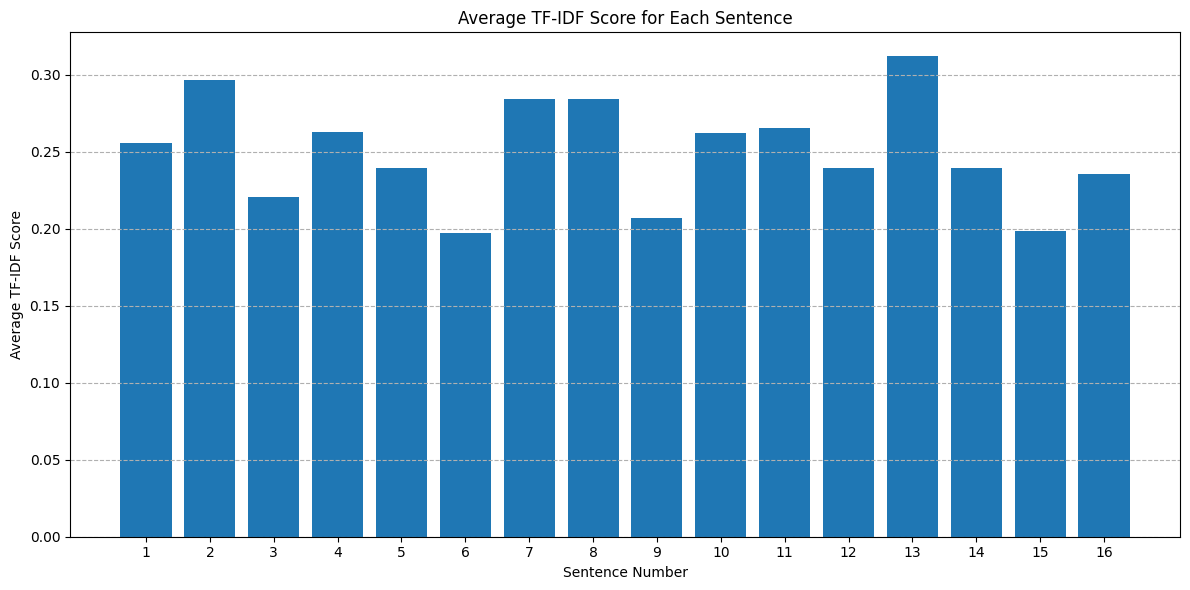

In [106]:
# Visualize the average TF-IDF scores as a histogram
plt.figure(figsize=(12, 6))
plt.bar(range(1, len(sentence_scores) + 1), sentence_scores)
plt.xlabel("Sentence Number")
plt.ylabel("Average TF-IDF Score")
plt.title("Average TF-IDF Score for Each Sentence")
plt.xticks(range(1, len(sentence_scores) + 1))
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

# Calculate Sentence Score

In [107]:
# Variable initialization
sent_index = 0
sentence_scores = [] #

# Calculate sentence TF-IDF score
print("--- Sentence TF-IDF Scores ---")
for idx, i in enumerate(tfidf_matrix):
    sent_score = i.sum()
    sent_length = len(i.data) # Number of words with non-zero TF-IDF
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    sentence_scores.append(avg_score)
    print(f"Sentence {idx+1}: TF-IDF Sum = {sent_score:.4f}, Word Count (non-zero TF-IDF) = {sent_length}, Average TF-IDF = {avg_score:.4f}")


--- Sentence TF-IDF Scores ---
Sentence 1: TF-IDF Sum = 3.8372, Word Count (non-zero TF-IDF) = 15, Average TF-IDF = 0.2558
Sentence 2: TF-IDF Sum = 3.2629, Word Count (non-zero TF-IDF) = 11, Average TF-IDF = 0.2966
Sentence 3: TF-IDF Sum = 4.1870, Word Count (non-zero TF-IDF) = 19, Average TF-IDF = 0.2204
Sentence 4: TF-IDF Sum = 3.6823, Word Count (non-zero TF-IDF) = 14, Average TF-IDF = 0.2630
Sentence 5: TF-IDF Sum = 4.0662, Word Count (non-zero TF-IDF) = 17, Average TF-IDF = 0.2392
Sentence 6: TF-IDF Sum = 4.9283, Word Count (non-zero TF-IDF) = 25, Average TF-IDF = 0.1971
Sentence 7: TF-IDF Sum = 3.1233, Word Count (non-zero TF-IDF) = 11, Average TF-IDF = 0.2839
Sentence 8: TF-IDF Sum = 3.4082, Word Count (non-zero TF-IDF) = 12, Average TF-IDF = 0.2840
Sentence 9: TF-IDF Sum = 3.9294, Word Count (non-zero TF-IDF) = 19, Average TF-IDF = 0.2068
Sentence 10: TF-IDF Sum = 3.6726, Word Count (non-zero TF-IDF) = 14, Average TF-IDF = 0.2623
Sentence 11: TF-IDF Sum = 3.7192, Word Count (no

In [108]:
print("\nList of average TF-IDF scores for each sentence:")
print(sentence_scores)


List of average TF-IDF scores for each sentence:
[np.float64(0.2558109212942385), np.float64(0.2966266898604991), np.float64(0.2203685198994809), np.float64(0.2630192233394888), np.float64(0.23918790505775156), np.float64(0.19713210796892094), np.float64(0.28393363120471826), np.float64(0.284018090515861), np.float64(0.20680812270047347), np.float64(0.26232762998468595), np.float64(0.26565939866942806), np.float64(0.23917253560377968), np.float64(0.31194202353468875), np.float64(0.23950268310634762), np.float64(0.19821407265374322), np.float64(0.23570226039551587)]


# Define Threshold

In [109]:

# Calculate the average of all sentence scores (threshold)
threshold = sum(sentence_scores) / len(sentence_scores) if sentence_scores else 0

print("\nThreshold (Average of Sentence Scores):", threshold)

# Initialize a list to store cleaned sentences
all_cleaned_sentences = []
for sentence in sentences:
    cleaned_sentence = stopword_remover.remove(sentence)
    all_cleaned_sentences.append(cleaned_sentence)

# Function to calculate TF for a term in a document
def calculate_tf(term, document):
    words = word_tokenize(document.lower())
    return words.count(term) / len(words) if len(words) > 0 else 0

# Function to calculate IDF for a term across all documents
def calculate_idf(term, all_documents):
    num_documents_with_term = sum(1 for doc in all_documents if term.lower() in word_tokenize(doc.lower()))
    if num_documents_with_term > 0:
        return math.log(len(all_documents) / num_documents_with_term)
    else:
        return 0

# Calculate TF-IDF for "investasi" in each sentence
tfidf_scores = {}
for i, sentence in enumerate(sentences):
    cleaned_sentence = stopword_remover.remove(sentence)
    tf = calculate_tf("investasi", cleaned_sentence)
    idf = calculate_idf("investasi", all_cleaned_sentences)
    tfidf = tf * idf
    tfidf_scores[f"Sentence {i+1}"] = tfidf

# Print the TF-IDF scores for "investasi" in each sentence
print("TF-IDF Score for 'investasi' in each cleaned sentence:")
for sentence_num, score in tfidf_scores.items():
    print(f"{sentence_num}: {score:.4f}")

# Calculate the overall IDF for "investasi" across all cleaned sentences
overall_idf_investasi = calculate_idf("investasi", all_cleaned_sentences)
print(f"\nOverall IDF for 'investasi': {overall_idf_investasi:.4f}")


# You can also use scikit-learn's TfidfVectorizer for a more direct approach:
vectorizer = TfidfVectorizer(stop_words=factory.get_stop_words())
tfidf_matrix = vectorizer.fit_transform(sentences)
feature_names = vectorizer.get_feature_names_out()

try:
    investasi_index = list(feature_names).index("investasi")
    print("\nTF-IDF Score for 'investasi' using TfidfVectorizer:")
    for i, sentence in enumerate(sentences):
        tfidf = tfidf_matrix[i, investasi_index]
        print(f"Sentence {i+1}: {tfidf:.4f}")
except ValueError:
    print("\n'investasi' not found in the vocabulary after stop word removal by TfidfVectorizer.")


Threshold (Average of Sentence Scores): 0.24996411348685135
TF-IDF Score for 'investasi' in each cleaned sentence:
Sentence 1: 0.0827
Sentence 2: 0.0000
Sentence 3: 0.0359
Sentence 4: 0.0551
Sentence 5: 0.0000
Sentence 6: 0.0000
Sentence 7: 0.0000
Sentence 8: 0.0000
Sentence 9: 0.0533
Sentence 10: 0.0459
Sentence 11: 0.0000
Sentence 12: 0.0413
Sentence 13: 0.0000
Sentence 14: 0.0394
Sentence 15: 0.0000
Sentence 16: 0.0000

Overall IDF for 'investasi': 0.8267

TF-IDF Score for 'investasi' using TfidfVectorizer:
Sentence 1: 0.3174
Sentence 2: 0.0000
Sentence 3: 0.1420
Sentence 4: 0.1765
Sentence 5: 0.0000
Sentence 6: 0.0000
Sentence 7: 0.0000
Sentence 8: 0.0000
Sentence 9: 0.2128
Sentence 10: 0.1676
Sentence 11: 0.0000
Sentence 12: 0.1502
Sentence 13: 0.0000
Sentence 14: 0.1639
Sentence 15: 0.0000
Sentence 16: 0.0000


# Get Sentences

In [110]:
# Final summary initialization
final_summ = ""

# Get summary sentences
print("\n**Summary Sentences (above or equal to the threshold):**")
for index, score in enumerate(sentence_scores):
    if score >= threshold:
        final_summ = final_summ + " " + sentences[index]
        print(f"- {sentences[index]}")

print("\n**Final Summary:**")
print(final_summ.strip())


**Summary Sentences (above or equal to the threshold):**
- Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar.
- Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.
- Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar.
- Presiden Prabowo menyampaikan masing-masing negara akan berkontribusi sebesar USD2 miliar dalam dana tersebut.
- Dana itu akan dikelola oleh BPI Danantara bersama dengan Qatar Investment Authority (QIA) dalam co-partnership.
- "Danantara Indonesia siap menjalankan mandat tersebut dengan menerapkan tata kelola investasi yang prudent, transparan, dan berorientasi pada hasil.
- Fokus kami adalah memastikan bahwa setiap proyek yang didanai memberikan dampak strategis dan berkelanjutan bagi perekonomian nasional," ujar Rosan.
- "Kemitraan ini merupakan langkah konk

# Summarization Result

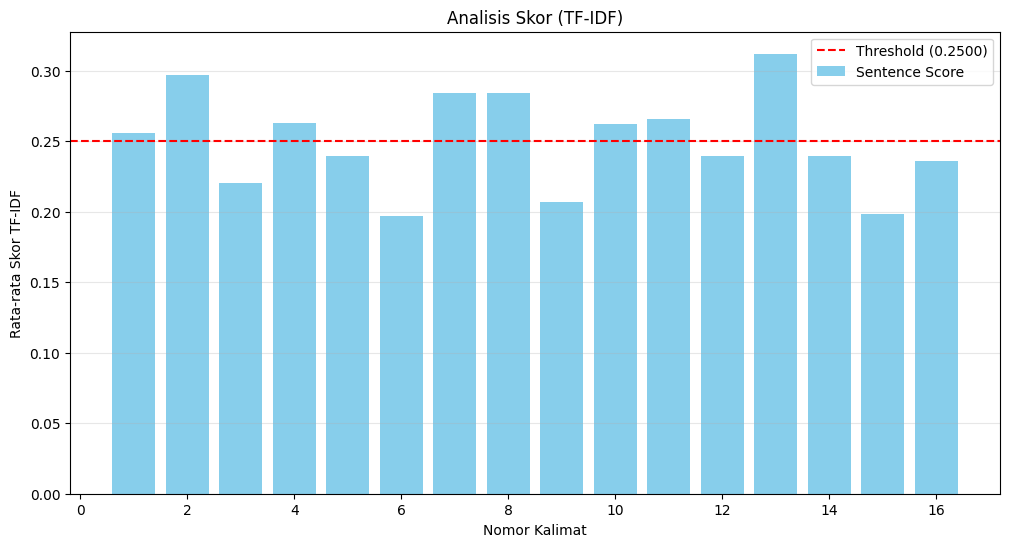


HASIL RINGKASAN AKHIR
Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar. Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha. Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar. Presiden Prabowo menyampaikan masing-masing negara akan berkontribusi sebesar USD2 miliar dalam dana tersebut. Dana itu akan dikelola oleh BPI Danantara bersama dengan Qatar Investment Authority (QIA) dalam co-partnership. "Danantara Indonesia siap menjalankan mandat tersebut dengan menerapkan tata kelola investasi yang prudent, transparan, dan berorientasi pada hasil. Fokus kami adalah memastikan bahwa setiap proyek yang didanai memberikan dampak strategis dan berkelanjutan bagi perekonomian nasional," ujar Rosan. "Kemitraan ini merupakan langkah konkret dalam membangun kepercayaan dengan mitra global

In [111]:
plt.figure(figsize=(12, 6))
plt.bar(range(1, len(sentence_scores) + 1), sentence_scores, color='skyblue', label='Sentence Score')
plt.axhline(y=threshold, color='r', linestyle='--', label=f'Threshold ({threshold:.4f})')
plt.xlabel("Nomor Kalimat")
plt.ylabel("Rata-rata Skor TF-IDF")
plt.title("Analisis Skor (TF-IDF)")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# ==========================================
# 8. Final Output
# ==========================================
print("\n" + "="*30)
print("HASIL RINGKASAN AKHIR")
print("="*30)
print(final_summary.strip())